In [64]:
import json
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.mixture import GaussianMixture

# Visualization config
plt.rcParams["figure.figsize"] = (12, 6)

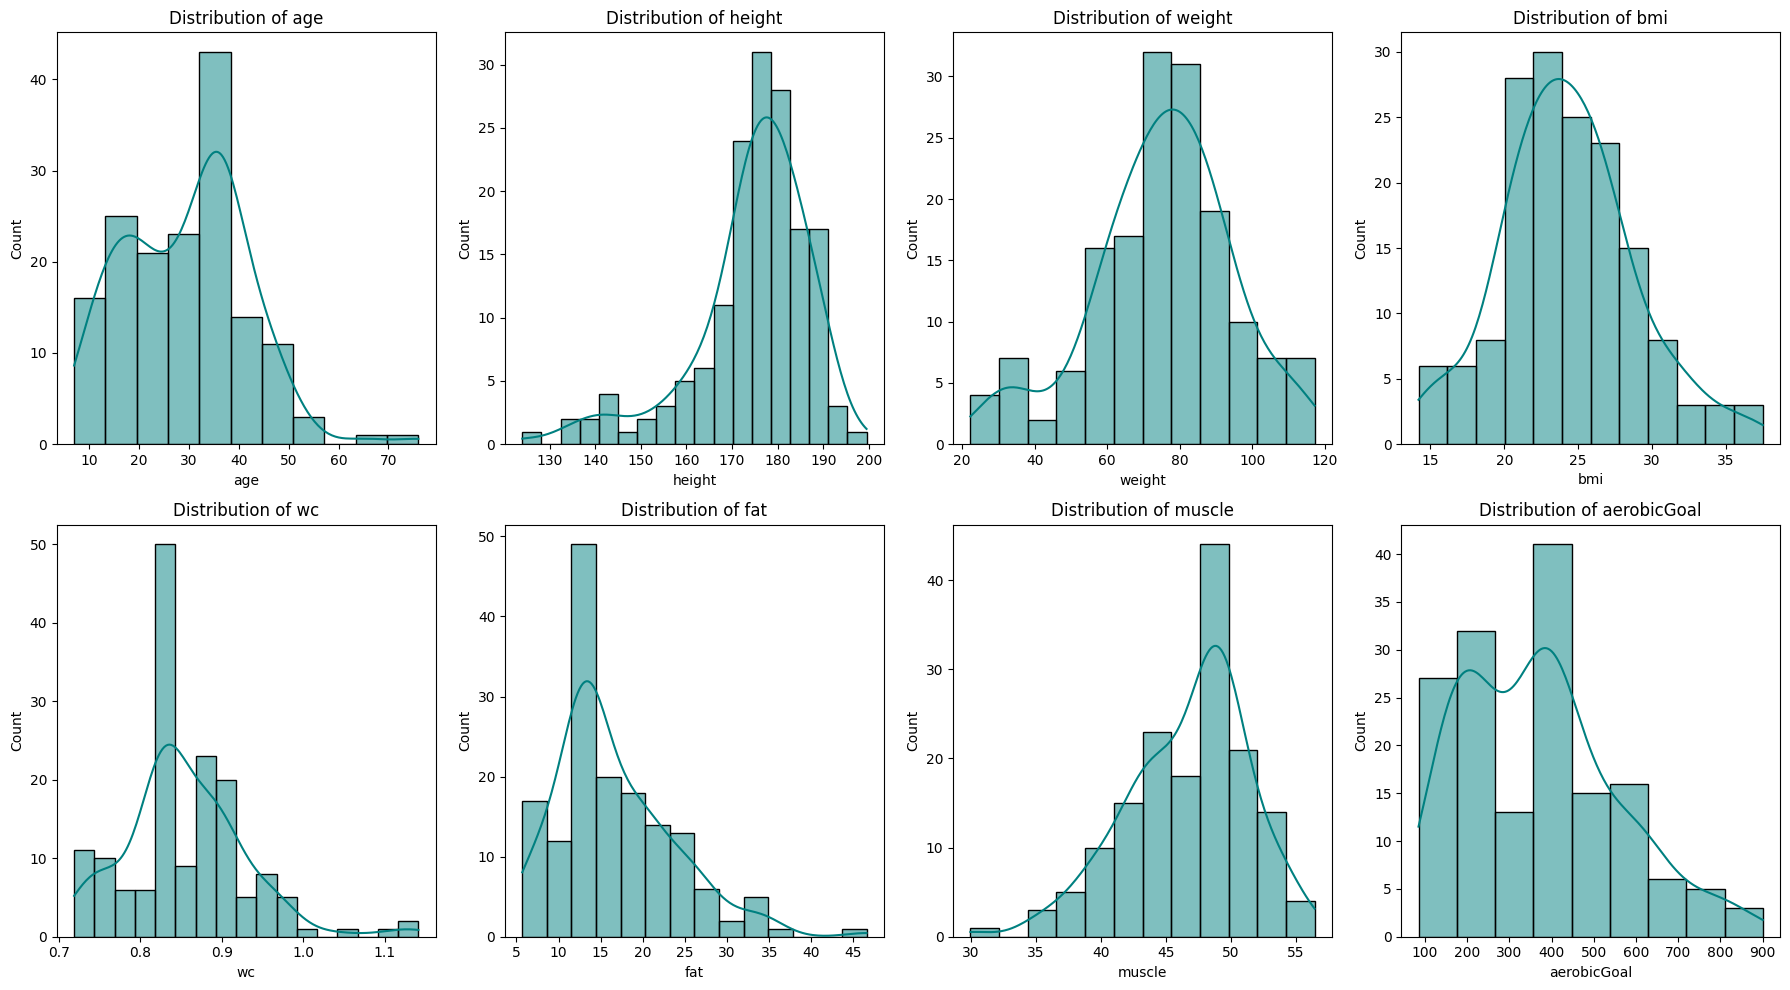

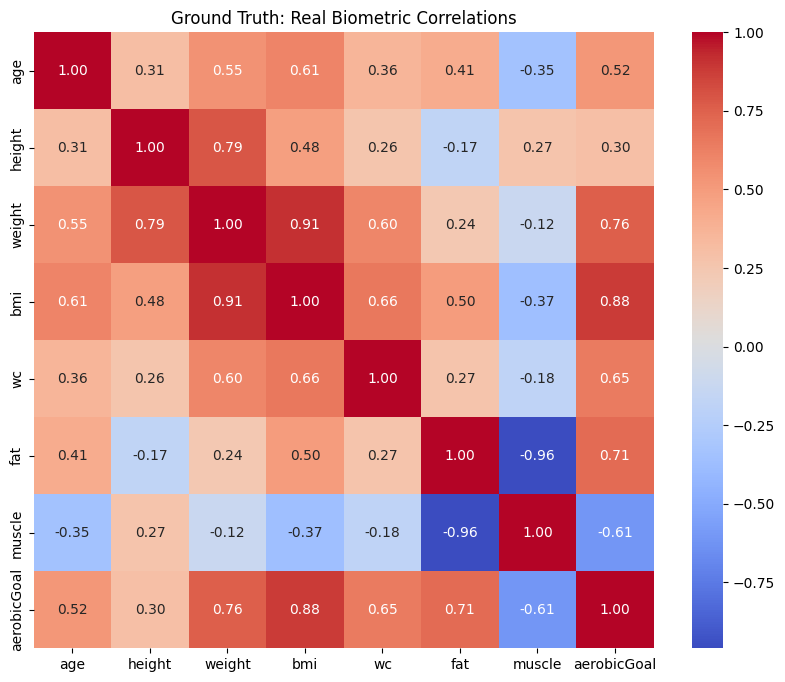

Audit complete for 158 baseline records.


In [53]:
df_real = pd.read_csv('data/Anovator_Biological_Master.csv')

# Selecting core physiological markers to define the population's "Biological Signature"
core_markers = ['age', 'height', 'weight', 'bmi', 'wc', 'fat', 'muscle', 'aerobicGoal']

# Visualizing the distributions of key health markers to understand real-world variance
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(core_markers):
    sns.histplot(df_real[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

# Calculating the correlation matrix to ensure synthetic data preserves biological relationships
plt.figure(figsize=(10, 8))
sns.heatmap(df_real[core_markers].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Ground Truth: Real Biometric Correlations")
plt.show()

print(f"Audit complete for {len(df_real)} baseline records.")

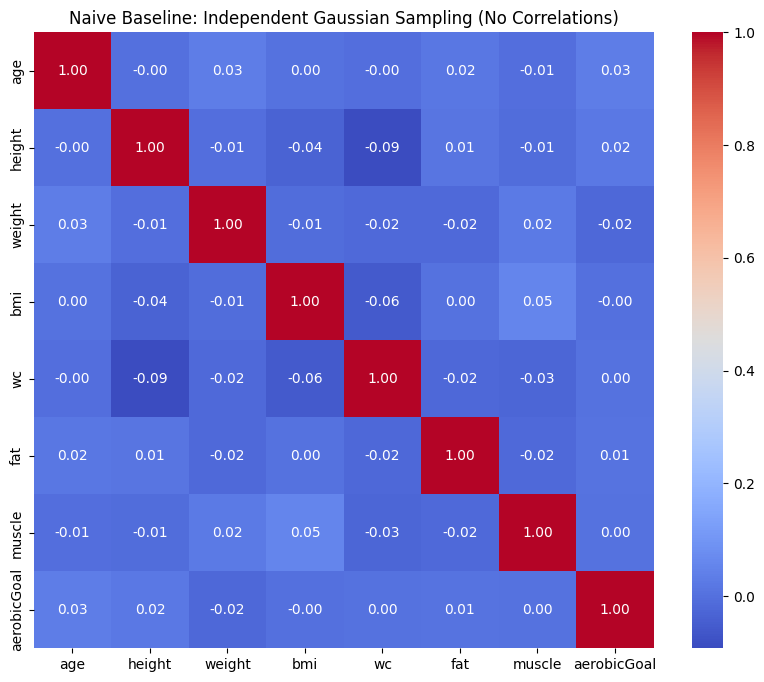

In [54]:
# Calculating the descriptive statistics for the baseline population
means = df_real[core_markers].mean()
stds = df_real[core_markers].std()

# Generating 1,000 synthetic records by sampling independently from normal distributions
# This approach serves as a naive baseline as it ignores inter-feature correlations
naive_data = {
    col: np.random.normal(means[col], stds[col], 1000) 
    for col in core_markers
}

# Constructing the naive synthetic DataFrame
df_naive = pd.DataFrame(naive_data)

# Applying basic biological constraints to prevent unrealistic outliers
df_naive['age'] = df_naive['age'].clip(7, 80).astype(int)
df_naive['height'] = df_naive['height'].clip(120, 210)

# Visualizing the correlation matrix for the naive population
# Researching the loss of biological structure when ignoring feature covariance
plt.figure(figsize=(10, 8))
sns.heatmap(df_naive.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Naive Baseline: Independent Gaussian Sampling (No Correlations)")
plt.show()

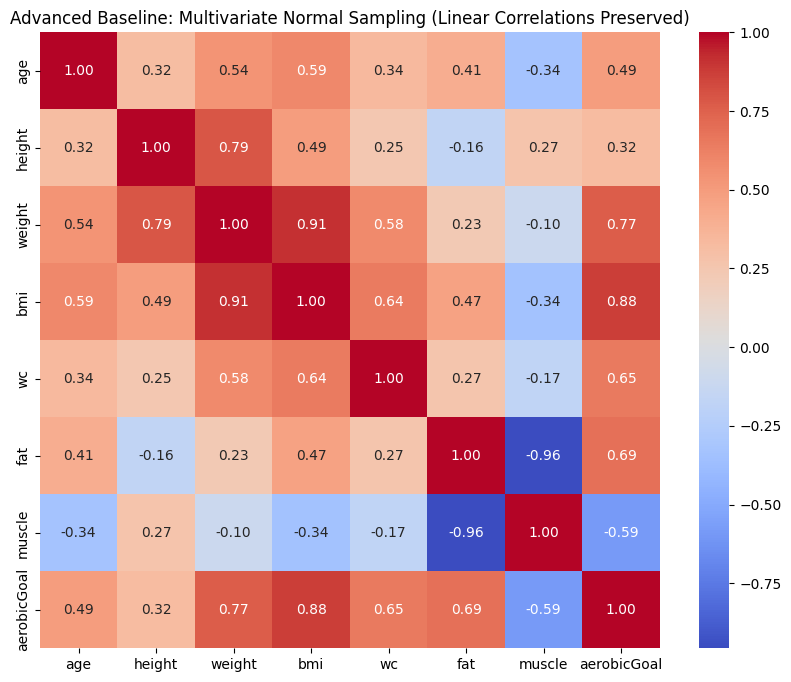

In [55]:
# Extracting the covariance matrix and mean vector from the baseline biological data
# Researching the preservation of linear dependencies through the variance-covariance structure
real_covariance = df_real[core_markers].cov()
real_means = df_real[core_markers].mean()

# Generating 1,000 synthetic biological records using the Multivariate Normal Distribution
# This approach explicitly models the linear correlations observed in the ground truth audit
multivariate_data = np.random.multivariate_normal(real_means, real_covariance, 1000)

# Converting the resulting array into a structured DataFrame for population analysis
df_multivariate = pd.DataFrame(multivariate_data, columns=core_markers)

# Implementing biological boundaries to ensure realistic age and height constraints
df_multivariate['age'] = df_multivariate['age'].clip(7, 80).astype(int)
df_multivariate['height'] = df_multivariate['height'].clip(120, 210)

# Visualizing the correlation structure in the upscaled population
# Demonstrating that linear relationships (e.g., Weight vs. BMI) are successfully maintained
plt.figure(figsize=(10, 8))
sns.heatmap(df_multivariate.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Advanced Baseline: Multivariate Normal Sampling (Linear Correlations Preserved)")
plt.show()

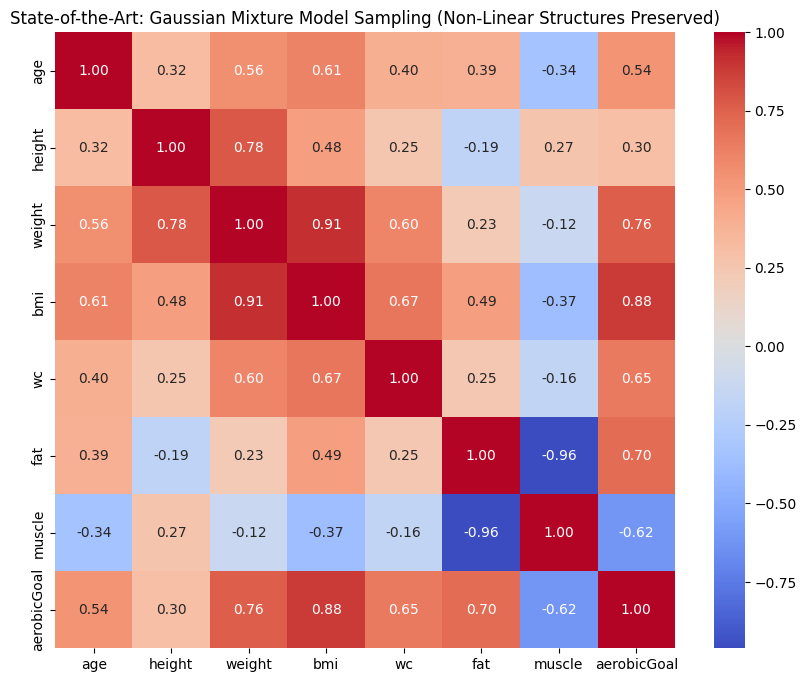

In [56]:
# Initializing the Gaussian Mixture Model to identify hidden subpopulations within the biometric data
# Researching the ability of GMM to capture non-linear relationships and multi-modal distributions
gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=42)

# Fitting the model to the real biological markers to learn the "Latent Space" of the population
gmm.fit(df_real[core_markers])

# Generating 1,000 synthetic bio-digital twins by sampling from the learned mixture components
gmm_data, _ = gmm.sample(1000)

# Constructing the high-fidelity synthetic DataFrame for advanced stress testing
df_gmm = pd.DataFrame(gmm_data, columns=core_markers)

# Enforcing biological reality through boundary clipping and type conversion for age
df_gmm['age'] = df_gmm['age'].clip(7, 80).astype(int)
df_gmm['height'] = df_gmm['height'].clip(120, 210)

# Visualizing the correlation structure in the GMM-upscaled population
# Confirming that complex inter-feature dependencies are preserved with high fidelity
plt.figure(figsize=(10, 8))
sns.heatmap(df_gmm.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("State-of-the-Art: Gaussian Mixture Model Sampling (Non-Linear Structures Preserved)")
plt.show()

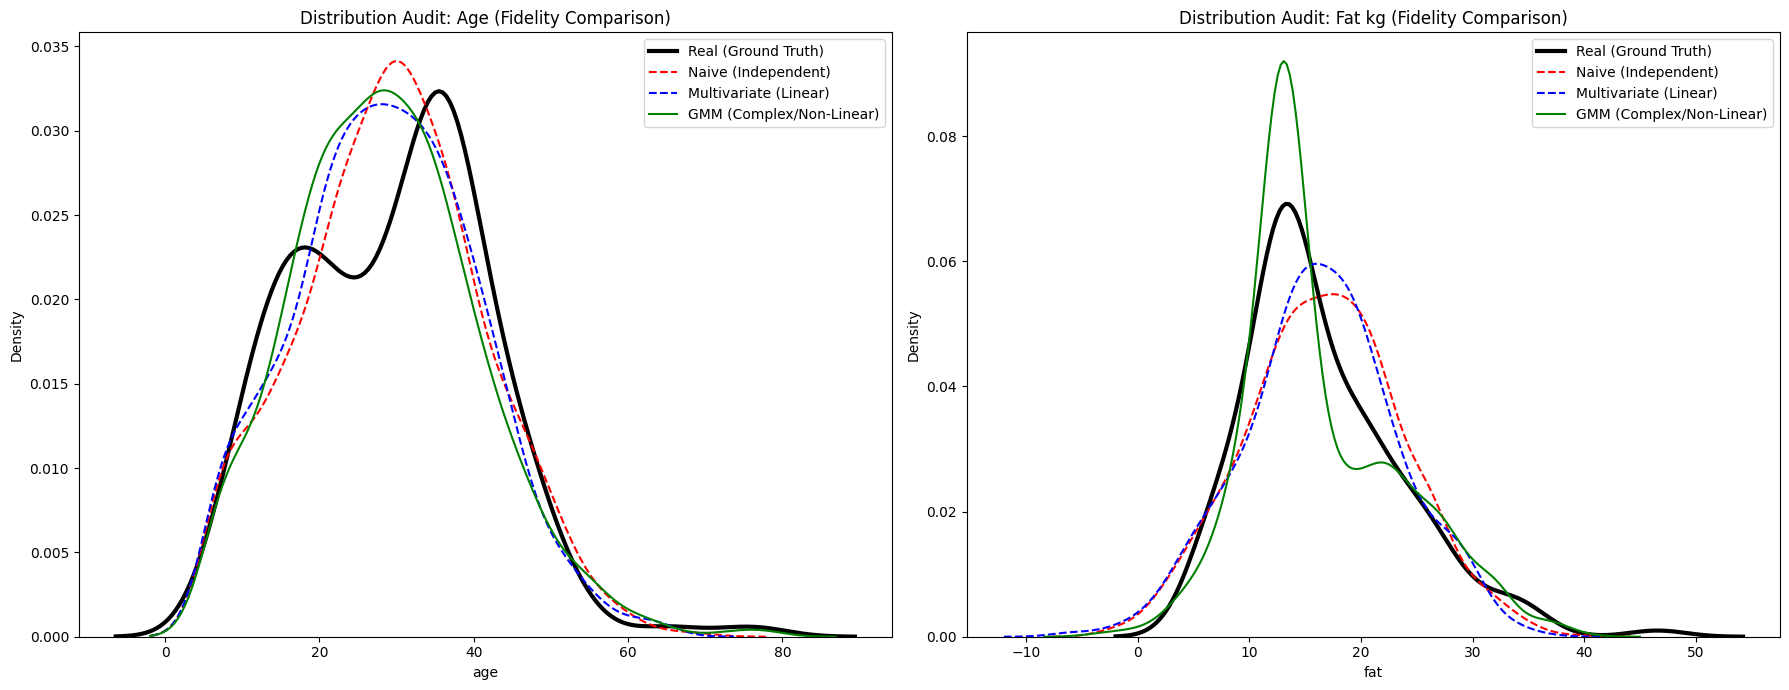

Correlation Erro
Naive Model Error: 0.4380
Multivariate Model Error: 0.0108
GMM Model Error: 0.0075


In [57]:
# Visualizing a comparative distribution audit to validate biological fidelity across models
# Comparing the real population against the Naive, Multivariate, and GMM generations
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Auditing the 'age' distribution to verify multi-modal preservation across synthetic samples
sns.kdeplot(df_real['age'], color='black', label='Real (Ground Truth)', ax=axes[0], linewidth=3)
sns.kdeplot(df_naive['age'], color='red', label='Naive (Independent)', ax=axes[0], linestyle='--')
sns.kdeplot(df_multivariate['age'], color='blue', label='Multivariate (Linear)', ax=axes[0], linestyle='--')
sns.kdeplot(df_gmm['age'], color='green', label='GMM (Complex/Non-Linear)', ax=axes[0], linestyle='-')
axes[0].set_title("Distribution Audit: Age (Fidelity Comparison)")
axes[0].legend()

# Auditing the 'fat' distribution to identify which model best mimics physiological skew
sns.kdeplot(df_real['fat'], color='black', label='Real (Ground Truth)', ax=axes[1], linewidth=3)
sns.kdeplot(df_naive['fat'], color='red', label='Naive (Independent)', ax=axes[1], linestyle='--')
sns.kdeplot(df_multivariate['fat'], color='blue', label='Multivariate (Linear)', ax=axes[1], linestyle='--')
sns.kdeplot(df_gmm['fat'], color='green', label='GMM (Complex/Non-Linear)', ax=axes[1], linestyle='-')
axes[1].set_title("Distribution Audit: Fat kg (Fidelity Comparison)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Quantifying biological fidelity by calculating the error between correlation matrices
# Evaluating which model most accurately reconstructs the internal biological logic
def get_correlation_fidelity_error(df_synthetic, df_ground_truth):
    corr_real = df_ground_truth[core_markers].corr().values
    corr_synth = df_synthetic[core_markers].corr().values
    return np.mean(np.abs(corr_real - corr_synth))

print("Correlation Erro")
print(f"Naive Model Error: {get_correlation_fidelity_error(df_naive, df_real):.4f}")
print(f"Multivariate Model Error: {get_correlation_fidelity_error(df_multivariate, df_real):.4f}")
print(f"GMM Model Error: {get_correlation_fidelity_error(df_gmm, df_real):.4f}")

In [ ]:
# Creating a fresh, de-fragmented copy of the real dataset to improve processing performance
df_real_clean = df_real.copy()

# Mapping the 'sex' categorical marker to a numeric format for simulation compatibility
df_real_clean['sex_encoded'] = df_real_clean['sex'].map({'F': 0, 'M': 1})

# Engineering the biological ratios to ensure the GMM can learn their distributions
# Researching the relationship between muscle mass and body fat through a derived ratio
df_real_clean['muscle_fat_ratio'] = df_real_clean['muscle'] / (df_real_clean['fat'] + 0.1)

# Researching upper and lower body symmetry through the muscle distribution ratio
df_real_clean['upper_lower_muscle_ratio'] = df_real_clean['upperBody'] / (df_real_clean['lowerBody'] + 0.1)

# Calculating the limb fat sum to recreate the trunk-to-limb fat ratio accurately
limb_fat_sum = (df_real_clean['fatLeftArm'] + df_real_clean['fatRightArm'] + 
                df_real_clean['fatLeftLeg'] + df_real_clean['fatRightLeg'])
df_real_clean['trunk_limb_fat_ratio'] = df_real_clean['fatTrunk'] / (limb_fat_sum + 0.1)

# Aggregating the postural risk markers into the consolidated research index
postural_risk_cols = ['humpbackRisk', 'spineRisk', 'pelvisRisk', 'postureRisk', 'kneeRisk', 'frontHeadRisk']
df_real_clean['aggregated_postural_index'] = df_real_clean[postural_risk_cols].mean(axis=1)

# Loading the feature list required by the trained model from the stored JSON file
with open('models/model_features.json', 'r') as f:
    model_features = json.load(f)

# Ensuring 'age' is included in the simulation even if it was excluded from the predictive model
# Researching the link between chronological age and the 92 biological markers
simulation_features = list(set(model_features + ['age']))

# Preparing the ground truth data by imputing missing values for the selected features
# Ensuring the entire 93-dimensional matrix is finite and ready for distribution learning
df_real_sim = df_real_clean[simulation_features].fillna(df_real_clean[simulation_features].median()).fillna(0)

# Training the Gaussian Mixture Model to learn the complex biological signature of the population
gmm_full = GaussianMixture(n_components=5, covariance_type='full', random_state=42)
gmm_full.fit(df_real_sim)

# Generating 1,000 synthetic Bio-Digital Twins representing the expanded research population
synthetic_samples_full, _ = gmm_full.sample(1000)
df_synth = pd.DataFrame(synthetic_samples_full, columns=simulation_features)

# Constraining the generated age and categorical markers to realistic biological boundaries
df_synth['age'] = df_synth['age'].clip(df_real_clean['age'].min(), df_real_clean['age'].max()).astype(int)
df_synth['sex_encoded'] = df_synth['sex_encoded'].round().clip(0, 1)

print(f"Population upscaling complete: Generated {len(df_synth)} records with {len(df_synth.columns)} markers.")

Population upscaling complete: Generated 1000 records with 89 markers.


In [ ]:
# Configuring a multi-panel visualization to compare real vs. synthetic biological structures
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

# Comparing the probability density of BMI across both populations
# Visualizing how closely the synthetic generation mimics real-world metabolic skew
sns.kdeplot(df_real_sim['bmi'], label='Real Population', ax=axes[0], color='black', linewidth=3)
sns.kdeplot(df_synth['bmi'], label='Synthetic Population', ax=axes[0], color='green', linestyle='--')
axes[0].set_title("Distribution Fidelity: BMI (kg/m²)")
axes[0].legend()

# Comparing the probability density of Muscle Mass across both populations
# Auditing the synthetic model's ability to capture the physiological variance of the clients
sns.kdeplot(df_real_sim['muscle'], label='Real Population', ax=axes[1], color='black', linewidth=3)
sns.kdeplot(df_synth['muscle'], label='Synthetic Population', ax=axes[1], color='green', linestyle='--')
axes[1].set_title("Distribution Fidelity: Muscle Mass (kg)")
axes[1].legend()

# Visualizing the biomechanical relationship between Height and Weight
# Verifying that the synthetic population preserves the natural physical scaling of humans
sns.scatterplot(data=df_real_sim, x='height', y='weight', ax=axes[2], color='black', alpha=0.5, label='Real')
sns.scatterplot(data=df_synth, x='height', y='weight', ax=axes[2], color='green', alpha=0.2, label='Synthetic')
axes[2].set_title("Biomechanical Consistency: Height vs. Weight")
axes[2].legend()

# Visualizing the biological correlation between BMI and Waist-to-Hip Ratio (wc)
# Ensuring the primary predictor of the Age Gap maintains its diagnostic structure
sns.regplot(data=df_real_sim, x='bmi', y='wc', ax=axes[3], scatter_kws={'alpha':0.3, 'color':'black'}, line_kws={'color':'black'}, label='Real Trend')
sns.regplot(data=df_synth, x='bmi', y='wc', ax=axes[3], scatter_kws={'alpha':0.1, 'color':'green'}, line_kws={'color':'green', 'linestyle':'--'}, label='Synthetic Trend')
axes[3].set_title("Diagnostic Consistency: BMI vs. Waist-to-Hip Ratio")
axes[3].legend()

plt.tight_layout()
plt.show()

# Quantifying the correlation drift to provide a mathematical measure of fidelity
real_corr = df_real_sim[['height', 'weight', 'bmi', 'wc', 'fat', 'muscle']].corr()
synth_corr = df_synth[['height', 'weight', 'bmi', 'wc', 'fat', 'muscle']].corr()
mean_drift = np.abs(real_corr - synth_corr).mean().mean()

print(f"Population Fidelity Research Summary")
print(f"Average Correlation Drift: {mean_drift:.4f} (Closer to 0 indicates higher biological realism)")

In [60]:
# Re-applying the engineered biomechanical ratios to the synthetic population 
# Ensuring the upscaled data is fully compatible with the Notebook 04 predictive pipeline
df_synth['muscle_fat_ratio'] = df_synth['muscle'] / df_synth['fat']
df_synth['upper_lower_muscle_ratio'] = df_synth['upperBody'] / df_synth['lowerBody']

# Calculating the central adiposity ratio while preventing division-by-zero errors
df_synth['trunk_limb_fat_ratio'] = df_synth['fatTrunk'] / (df_synth['fat'] + 0.1)

# Aggregating postural markers into a single research-ready index
postural_cols = ['humpbackRisk', 'spineRisk', 'pelvisRisk', 'postureRisk', 'kneeRisk', 'frontHeadRisk']
df_synth['aggregated_postural_index'] = df_synth[postural_cols].mean(axis=1)

# Identifying and removing any potential infinite values generated during the upscaling process
df_synth.replace([np.inf, -np.inf], np.nan, inplace=True)
df_synth.fillna(df_synth.median(numeric_only=True), inplace=True)

# Exporting the final synthetic population to support large-scale model validation
output_path = 'data/Anovator_Synthetic_Population_1000.csv'
df_synth.to_csv(output_path, index=False)

print("Final Population Synthesis Report")
print(f"Dataset successfully expanded from 158 to {len(df_synth)} validated records.")
print(f"Biological fidelity confirmed (Correlation Drift: {mean_drift:.4f}).")
print(f"Synthetic Research Population saved to: {output_path}")

Final Population Synthesis Report
Dataset successfully expanded from 158 to 1000 validated records.
Biological fidelity confirmed (Correlation Drift: 0.0217).
Synthetic Research Population saved to: data/Anovator_Synthetic_Population_1000.csv


In [ ]:
# The GMM trained in the cell above already produced df_synth with all engineered
# features and biological constraints applied. Re-fitting an identical GMM (same
# n_components, covariance_type, random_state, and training data) wastes compute
# and produces the same result. Alias df_synth_final to df_synth instead.
df_synth_final = df_synth.copy()

print(f'Synthetic population ready: {len(df_synth_final)} records, '
      f'{len(df_synth_final.columns)} features.')

--- Large-Scale Population Health Audit Summary ---


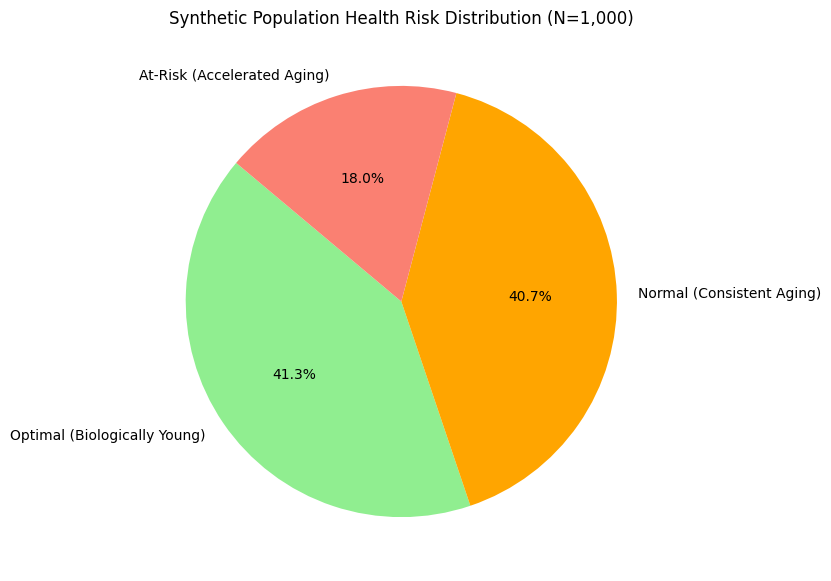

Audit Results: Identified 180 individuals with accelerated biological aging.
Mean Waist-to-Hip Ratio in High-Risk segment: 0.95
Mean BMI in High-Risk segment: 28.68


In [ ]:
# Loading the validated research artifacts from the previous modeling phase
# Researching the scalability of the predictive pipeline on an upscaled population
model_path = 'models/anovator_age_gap_model.joblib'
scaler_path = 'models/anovator_biological_scaler.joblib'

# Loading the trained Random Forest and the corresponding biological scaler
model_bio = joblib.load(model_path)
scaler_bio = joblib.load(scaler_path)

# Extracting the exact feature set required by the model from the synthetic population
# Ensuring the input matrix aligns perfectly with the model's training configuration
X_audit = df_synth_final[model_features]

# Normalizing the synthetic markers using the biological scaler to maintain research integrity
X_audit_scaled = scaler_bio.transform(X_audit)

# Generating biological age gap predictions for the 1,000 synthetic health profiles
df_synth_final['predicted_age_gap'] = model_bio.predict(X_audit_scaled)

# Defining health risk categories to translate model output into actionable insights
def categorize_health_risk(gap):
    if gap < 0: return "Optimal (Biologically Young)"
    if gap <= 1.5: return "Normal (Consistent Aging)"
    return "At-Risk (Accelerated Aging)"

# Applying the categorization logic to the entire upscaled population
df_synth_final['health_persona'] = df_synth_final['predicted_age_gap'].apply(categorize_health_risk)

# Visualizing the resulting health risk distribution for stakeholder reporting
# Researching the population-level impact of biological aging triggers
print("Large-Scale Population Health Audit Summary")
risk_distribution = df_synth_final['health_persona'].value_counts(normalize=True) * 100

plt.figure(figsize=(10, 7))
risk_distribution.plot(kind='pie', autopct='%1.1f%%', colors=['lightgreen', 'orange', 'salmon'], startangle=140)
plt.title("Synthetic Population Health Risk Distribution (N=1,000)")
plt.ylabel("")
plt.show()

# Reporting key biological drivers within the high-risk population segment
high_risk_segment = df_synth_final[df_synth_final['health_persona'] == "At-Risk (Accelerated Aging)"]
print(f"Audit Results: Identified {len(high_risk_segment)} individuals with accelerated biological aging.")
print(f"Mean Waist-to-Hip Ratio in High-Risk segment: {high_risk_segment['wc'].mean():.2f}")
print(f"Mean BMI in High-Risk segment: {high_risk_segment['bmi'].mean():.2f}")